In [2]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import yaml
from cmbml.utils.planck_cmap import colombi1_cmap

In [3]:

masterdir = '/bigdata/seth/datasets/'
Nside = 64
dir = masterdir + 'IQU_'+str(Nside)+'_1-1/PyILC_CNILC_Test_bt*_bs199/NILC_B_Predict/Test/sim0000/cmb_pred.fits'
pixdir = masterdir + 'IQU_'+str(Nside)+'_1-1/PyILC_CNILC_Test_bt*_bs199/Analysis_F_Pixel_Report/pixel_report.yaml'
ground = '/bigdata/seth/datasets/IQU_'+str(Nside)+'_1-1/Simulation/Test/sim0000/cmb_map_fid.fits'
ins = [0.001]

def plot_maps(dir,ins,groundtruth = None,shift = 0,rng = 500,maskdir = '/bigdata/seth/datasets/IQU_128_1-1/Simulation_Mask/mask.fits'):
    l = dir.split('*')
    mask = hp.read_map(maskdir)
    if groundtruth != None:
        truth = hp.read_map(groundtruth)
    for i in range(len(ins)):
        cop = l[:]
        cop.insert(1,str(ins[i]))
        cop = ''.join(cop)
        map = hp.read_map(cop)+shift
        hp.mollview(map,cmap='nipy_spectral',max = rng, min = -rng,title = ins[i])
        # hp.mollview(map*mask,cmap='nipy_spectral',max = rng, min = -rng,title = ins[i])
        if groundtruth != None:
            diff = (truth-map)
            diff = mask*(truth-map)
            hp.mollview(diff,cmap='seismic',max = rng, min = -rng,title = 'Diff '+ str(ins[i]))

def temp_hist(dir,ins,groundtruth,rng = [-200,200],shift = 0, binnumber = 1000, maskdir = '/bigdata/seth/datasets/IQU_512_1-1/Simulation_Mask/mask_smooth_512.fits'):
    l = dir.split('*')
    mask = hp.read_map(maskdir)
    bins = np.linspace(rng[0],rng[1],binnumber)
    if groundtruth != None:
        truth = hp.read_map(groundtruth)
    for i in range(len(ins)):
        cop = l[:]
        cop.insert(1,str(ins[i]))
        cop = ''.join(cop)
        map = hp.read_map(cop) + shift
        diff = mask*(truth-map)
        diff2 = diff[mask>0.5]
        print('Mean Value:',np.mean(diff2))
        plt.hist(diff2,bins)

def pixel_analysis(dir,ins,selector='r2'):
    l = dir.split('*')
    ylist =[]
    for i in range(len(ins)):
        cop = l[:]
        cop.insert(1,str(ins[i]))
        cop = ''.join(cop)
        with open(cop) as f:
            [p]= yaml.safe_load(f)
        ylist.append(p[selector])
        print(ylist)
    plt.plot(np.array(ins),np.array(ylist),'.-')
    plt.xscale('log')


summask = np.sum(mask)
summ = 0
for i in range(0,len(map)):
        summ += map[i]*mask[i]
shift = summ/summask
print('Shift',shift,'npMean',np.mean(map))
nomono = map-shift*mask

NameError: name 'mask' is not defined

In [18]:
def disply(path,label = 'CMB_Display',rng=500):
    mapp = hp.read_map(path)
    hp.mollview(mapp,cmap = colombi1_cmap,min = -rng, max = rng,title=label)
    return mapp


Plotting Maps

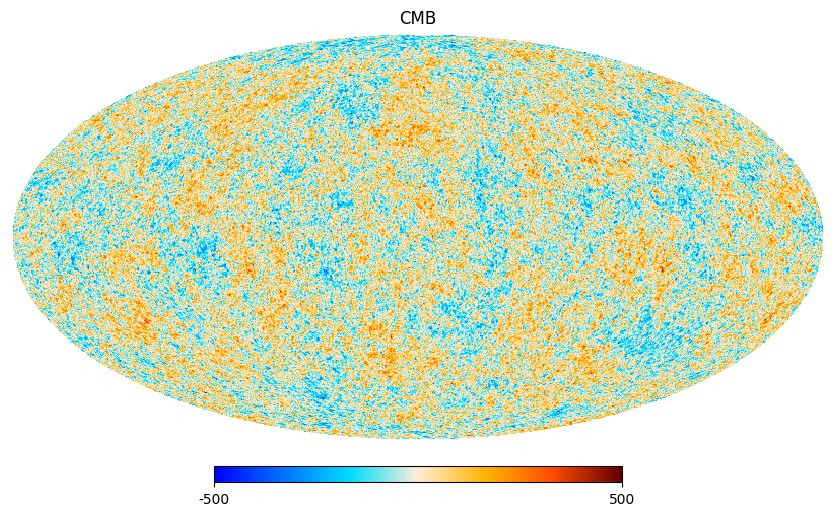

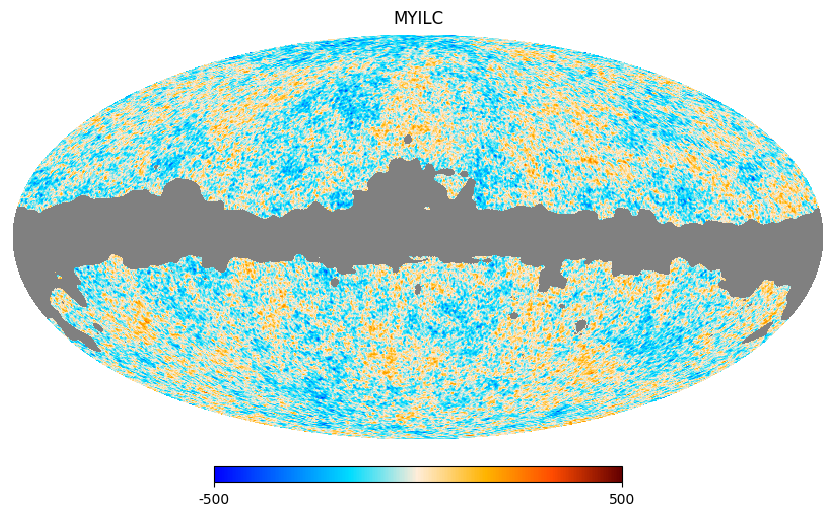

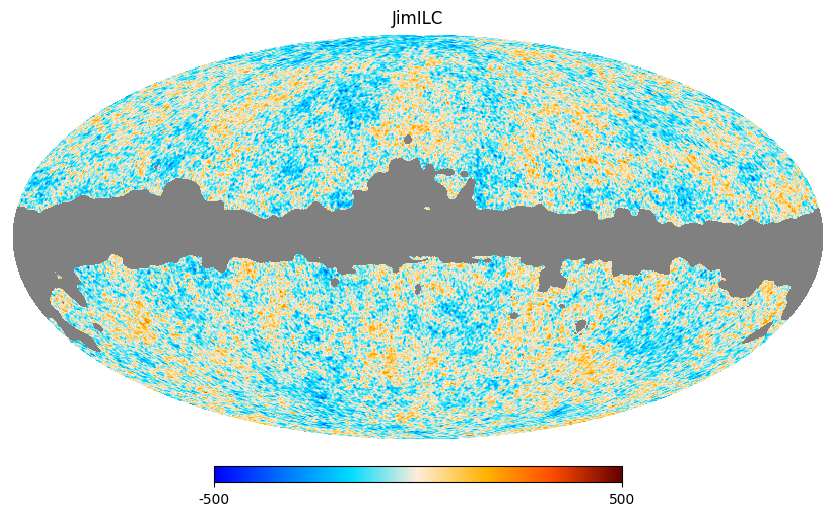

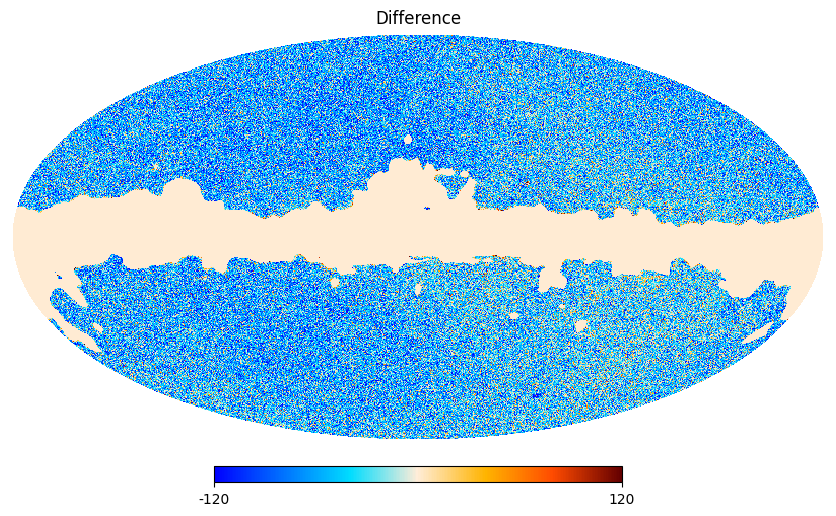

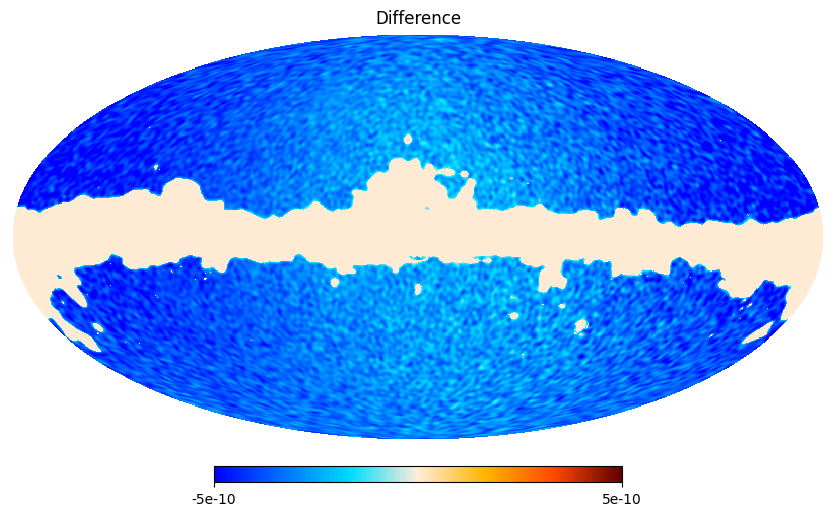

In [34]:
ilc = hp.read_map('/bigdata/seth/datasets/IQU_512_1-1/PyILC_CNILC_Test_lp[200, 715, 1025]/NILC_B_Predict/Test/sim0000/cmb_pred.fits')
cmb = disply('/bigdata/seth/datasets/IQU_512_1-1/Simulation/Test/sim0000/cmb_map_fid.fits',label='CMB')
mask = hp.read_map('/bigdata/seth/datasets/IQU_512_1-1/Simulation_Mask/mask.fits')
jimilc = hp.read_map('/bigdata/seth/datasets_stored/cmb_pred 1.fits')
for i in range(0,len(ilc)):
    if mask[i] == 0:
        ilc[i] = hp.UNSEEN
        jimilc[i] = hp.UNSEEN
#ilc = hp.remove_dipole(ilc)
#jimilc = hp.remove_dipole(jimilc)
hp.mollview(ilc, cmap= colombi1_cmap,min=-500,max=500,title='MYILC')
hp.mollview(jimilc, cmap= colombi1_cmap,min=-500,max=500,title='JimILC')
hp.mollview((ilc-cmb)*mask,cmap = colombi1_cmap,min=-120,max=120,title = 'Difference')
hp.mollview((jimilc-ilc)*mask,cmap = colombi1_cmap,min=-5e-10,max=5e-10,title = 'Difference')
for i in range(0,len(ilc)):
    if jimilc[i]-ilc[i] > 1e-9:
        print(jimilc[i]-ilc[i])

In [10]:
def remove_mono(mapp,mask):
    summask = np.sum(mask)
    summ = 0
    for i in range(0,len(mapp)):
        summ += mapp[i]*mask[i]
    shift = summ/summask
    nomono = mapp-shift*mask
    return nomono